In [34]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd

pengeluaran_df = pd.read_csv("pengeluaran.csv")
pemasukan_df = pd.read_csv("pemasukan.csv")

In [35]:
pengeluaran_df.head(), pemasukan_df.head()

(   id_pengeluaran  id_user             kategori  jumlah   tanggal
 0               1        1  Makanan dan Minuman   10000  1/4/2024
 1               2        1  Makanan dan Minuman   12000  1/4/2024
 2               3        1       Paket Internet   50000  1/4/2024
 3               4        1                  Kos  500000  1/4/2024
 4               5        1  Makanan dan Minuman   15000  2/4/2024,
    id_pemasukan  id_user              sumber   jumlah   tanggal
 0             1        1  Uang saku Orangtua  2000000  1/4/2024
 1             2        1  Uang saku Orangtua  1000000  2/5/2024
 2             3        1           Gaji/upah   500000  3/5/2024
 3             4        1  Uang saku Orangtua  1000000  1/6/2024
 4             5        1            Beasiswa  1000000  3/6/2024)

In [36]:
# Ubah kolom tanggal menjadi datetime
pengeluaran_df['tanggal'] = pd.to_datetime(pengeluaran_df['tanggal'], dayfirst=True)
pemasukan_df['tanggal'] = pd.to_datetime(pemasukan_df['tanggal'], dayfirst=True)

# Tambahkan kolom bulan-tahun
pengeluaran_df['bulan'] = pengeluaran_df['tanggal'].dt.to_period('M')
pemasukan_df['bulan'] = pemasukan_df['tanggal'].dt.to_period('M')

# Agregasi total pengeluaran dan pemasukan per bulan
pengeluaran_bulanan = pengeluaran_df.groupby('bulan')['jumlah'].sum().reset_index(name='total_pengeluaran')
pemasukan_bulanan = pemasukan_df.groupby('bulan')['jumlah'].sum().reset_index(name='total_pemasukan')

# Gabungkan kedua data tersebut
data = pd.merge(pemasukan_bulanan, pengeluaran_bulanan, on='bulan', how='outer').fillna(0)
data

,bulan,total_pemasukan,total_pengeluaran
0,2024-04,2000000,1285000
1,2024-05,1500000,1299000
2,2024-06,2000000,1233000
3,2024-07,2500000,1252000
4,2024-08,1500000,1236000
5,2024-09,1500000,1263000
6,2024-10,1500000,1222000
7,2024-11,1500000,1248000
8,2024-12,3000000,1264000
9,2025-01,1500000,1261000


In [37]:
# Hitung fitur tambahan: tabungan dan rasio pengeluaran terhadap pemasukan
data['tabungan'] = data['total_pemasukan'] - data['total_pengeluaran']
data['rasio_pengeluaran'] = data['total_pengeluaran'] / data['total_pemasukan']

# Isi NaN rasio (jika pemasukan nol) dengan nol
data['rasio_pengeluaran'] = data['rasio_pengeluaran'].fillna(0)
data

,bulan,total_pemasukan,total_pengeluaran,tabungan,rasio_pengeluaran
0,2024-04,2000000,1285000,715000,0.642500
1,2024-05,1500000,1299000,201000,0.866000
2,2024-06,2000000,1233000,767000,0.616500
3,2024-07,2500000,1252000,1248000,0.500800
4,2024-08,1500000,1236000,264000,0.824000
5,2024-09,1500000,1263000,237000,0.842000
6,2024-10,1500000,1222000,278000,0.814667
7,2024-11,1500000,1248000,252000,0.832000
8,2024-12,3000000,1264000,1736000,0.421333
9,2025-01,1500000,1261000,239000,0.840667


In [38]:
# Siapkan fitur untuk clustering
fitur_clustering = data[['total_pemasukan', 'total_pengeluaran', 'tabungan', 'rasio_pengeluaran']]

# Normalisasi
scaler = StandardScaler()
fitur_scaled = scaler.fit_transform(fitur_clustering)
fitur_scaled

array([[ 0.23717082,  1.41886939,  0.17194611, -0.39922435],
       [-0.79056942,  2.05491429, -0.87827685,  1.04170278],
       [ 0.23717082, -0.94358309,  0.27819435, -0.56684898],
       [ 1.26491106, -0.0803793 ,  1.26099055, -1.31277859],
       [-0.79056942, -0.80728776, -0.74955302,  0.77092453],
       [-0.79056942,  0.41937026, -0.80472038,  0.88697235],
       [-0.79056942, -1.44333266, -0.72094773,  0.71075158],
       [-0.79056942, -0.26210642, -0.77407185,  0.82250134],
       [ 2.2926513 ,  0.46480204,  2.25808939, -1.82510824],
       [-0.79056942,  0.32850671, -0.80063391,  0.87837622],
       [ 0.23717082, -0.76185598,  0.27002141, -0.55395478],
       [ 1.26491106, -1.17074199,  1.31002819, -1.37467076],
       [-0.79056942,  0.78282449, -0.82106626,  0.92135689]])

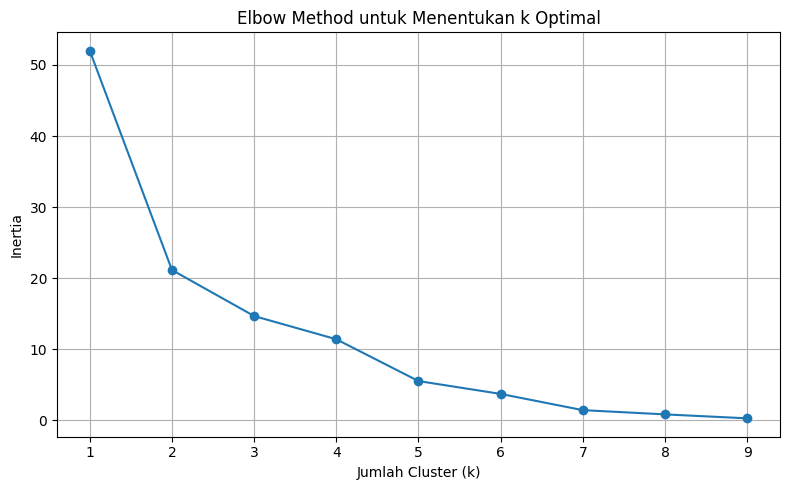

In [39]:
# Gunakan Elbow Method
inertia = []
k_range = range(1, 10)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(fitur_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method untuk Menentukan k Optimal')
plt.grid(True)
plt.tight_layout()
plt.show()

In [40]:
# Misal dari Elbow plot kamu memilih k = 3
k_optimal = 3
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init='auto')
data['cluster'] = kmeans_final.fit_predict(fitur_scaled)
data

,bulan,total_pemasukan,total_pengeluaran,tabungan,rasio_pengeluaran,cluster
0,2024-04,2000000,1285000,715000,0.642500,2
1,2024-05,1500000,1299000,201000,0.866000,2
2,2024-06,2000000,1233000,767000,0.616500,1
3,2024-07,2500000,1252000,1248000,0.500800,1
4,2024-08,1500000,1236000,264000,0.824000,0
5,2024-09,1500000,1263000,237000,0.842000,0
6,2024-10,1500000,1222000,278000,0.814667,0
7,2024-11,1500000,1248000,252000,0.832000,0
8,2024-12,3000000,1264000,1736000,0.421333,1
9,2025-01,1500000,1261000,239000,0.840667,0


In [41]:
# Hitung rata-rata rasio pengeluaran per cluster untuk labelisasi
cluster_mean = data.groupby('cluster')['rasio_pengeluaran'].mean().sort_values()
cluster_mean

cluster
1    0.529667
2    0.754250
0    0.833444
Name: rasio_pengeluaran, dtype: float64

In [43]:
# Mapping label berdasarkan urutan rasio pengeluaran (kecil=hemat, sedang=seimbang, tinggi=boros)
label_mapping = {
    cluster_mean.index[0]: 'Hemat',
    cluster_mean.index[1]: 'Normal',
    cluster_mean.index[2]: 'Boros'
}

data['tipe_pengeluaran'] = data['cluster'].map(label_mapping)
data

,bulan,total_pemasukan,total_pengeluaran,tabungan,rasio_pengeluaran,cluster,tipe_pengeluaran
0,2024-04,2000000,1285000,715000,0.642500,2,Normal
1,2024-05,1500000,1299000,201000,0.866000,2,Normal
2,2024-06,2000000,1233000,767000,0.616500,1,Hemat
3,2024-07,2500000,1252000,1248000,0.500800,1,Hemat
4,2024-08,1500000,1236000,264000,0.824000,0,Boros
5,2024-09,1500000,1263000,237000,0.842000,0,Boros
6,2024-10,1500000,1222000,278000,0.814667,0,Boros
7,2024-11,1500000,1248000,252000,0.832000,0,Boros
8,2024-12,3000000,1264000,1736000,0.421333,1,Hemat
9,2025-01,1500000,1261000,239000,0.840667,0,Boros


In [44]:
# Statistik deskriptif untuk tiap cluster
deskripsi_per_cluster = data.groupby('tipe_pengeluaran')[['total_pemasukan', 'total_pengeluaran', 'tabungan', 'rasio_pengeluaran']].describe()

# Tampilkan hasil
deskripsi_per_cluster

total_pemasukan                                       \
                           count       mean            std        min   
tipe_pengeluaran                                                        
Boros                        6.0  1500000.0       0.000000  1500000.0   
Hemat                        5.0  2400000.0  418330.013267  2000000.0   
Normal                       2.0  1750000.0  353553.390593  1500000.0   

                                                              \
                        25%        50%        75%        max   
tipe_pengeluaran                                               
Boros             1500000.0  1500000.0  1500000.0  1500000.0   
Hemat             2000000.0  2500000.0  2500000.0  3000000.0   
Normal            1625000.0  1750000.0  1875000.0  2000000.0   

                 total_pengeluaran                ...   tabungan             \
                             count          mean  ...        75%        max   
tipe_pengeluaran                                  ...                         
Boros                          6.0  1.250167e+06  ...   261000.0   278000.0   
Hemat                          5.0  1.242800e+06  ...  1272000.0  1736000.0   
Normal                         2.0  1.292000e+06  ...   586500.0   715000.0   

                 rasio_pengeluaran                                          \
                             count      mean       std       min       25%   
tipe_pengeluaran                                                             
Boros                          6.0  0.833444  0.012346  0.814667  0.826000   
Hemat                          5.0  0.529667  0.085849  0.421333  0.491200   
Normal                         2.0  0.754250  0.158038  0.642500  0.698375   

                                                
                       50%       75%       max  
tipe_pengeluaran                                
Boros             0.836333  0.841667  0.847333  
Hemat             0.500800  0.616500  0.618500  
Normal            0.754250  0.810125  0.866000  

[3 rows x 32 columns]

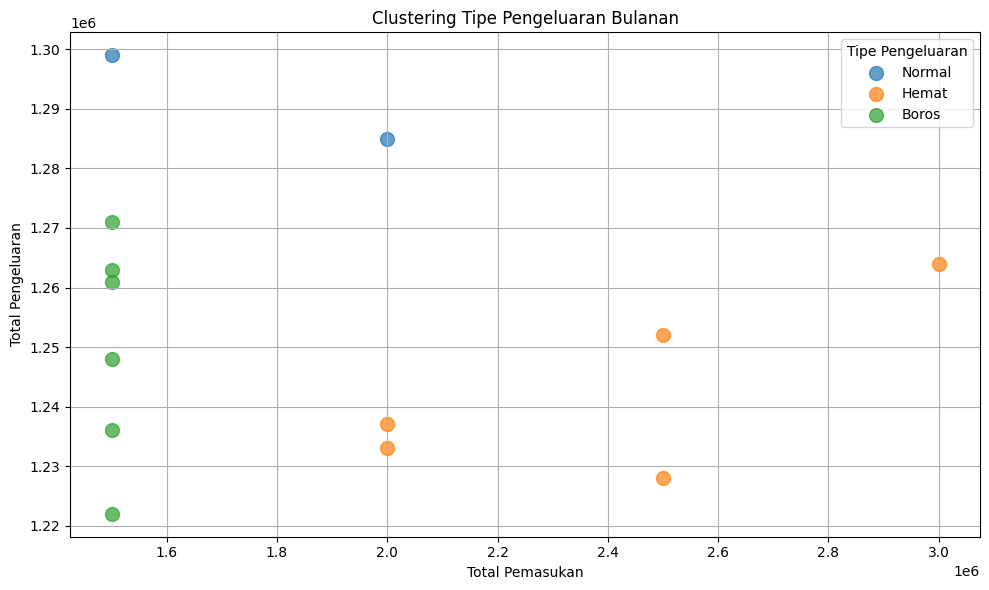

In [45]:
plt.figure(figsize=(10, 6))

# Scatter plot per label
for label in data['tipe_pengeluaran'].unique():
    subset = data[data['tipe_pengeluaran'] == label]
    plt.scatter(
        subset['total_pemasukan'],
        subset['total_pengeluaran'],
        label=label,
        s=100,
        alpha=0.7
    )

plt.xlabel('Total Pemasukan')
plt.ylabel('Total Pengeluaran')
plt.title('Clustering Tipe Pengeluaran Bulanan')
plt.legend(title='Tipe Pengeluaran')  # Menampilkan legenda dengan label
plt.grid(True)
plt.tight_layout()
plt.show()

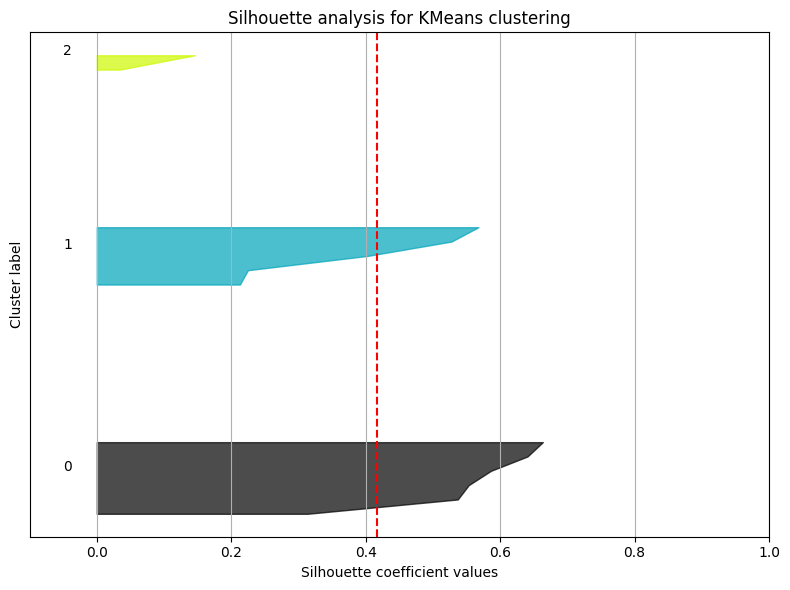

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_samples, silhouette_score

# Gunakan hasil clustering yang sudah dilakukan sebelumnya
labels = data['cluster']
silhouette_avg = silhouette_score(fitur_scaled, labels)
sample_silhouette_values = silhouette_samples(fitur_scaled, labels)

# Jumlah cluster
n_clusters = len(np.unique(labels))

# Buat plot
fig, ax = plt.subplots(figsize=(8, 6))

y_lower = 10
for i in range(n_clusters):
    ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
    ith_cluster_silhouette_values.sort()
    
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = plt.cm.nipy_spectral(float(i) / n_clusters)
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, ith_cluster_silhouette_values,
                     facecolor=color, edgecolor=color, alpha=0.7)

    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10  # jarak antar cluster

# Tambahkan garis vertikal untuk silhouette score rata-rata
ax.axvline(x=silhouette_avg, color="red", linestyle="--")

ax.set_title("Silhouette analysis for KMeans clustering")
ax.set_xlabel("Silhouette coefficient values")
ax.set_ylabel("Cluster label")
ax.set_yticks([])  # Hilangkan label Y
ax.set_xlim([-0.1, 1])
ax.grid(True)

plt.tight_layout()
plt.show()


In [152]:
import pickle

# Simpan model KMeans
with open('kmeans_model.pkl', 'wb') as file_model:
    pickle.dump(kmeans_final, file_model)

# Simpan StandardScaler
with open('scaler.pkl', 'wb') as file_scaler:
    pickle.dump(scaler, file_scaler)

In [153]:
# Load model dan scaler
with open('kmeans_model.pkl', 'rb') as file_model:
    kmeans_loaded = pickle.load(file_model)

with open('scaler.pkl', 'rb') as file_scaler:
    scaler_loaded = pickle.load(file_scaler)

In [ ]:
import mlflow
import mlflow.sklearn
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Set nama eksperimen
mlflow.set_experiment("Clustering_Pengeluaran")

with mlflow.start_run(run_name=f"KMeans_k={k_optimal}"):

    # Log parameter
    mlflow.log_param("jumlah_cluster", k_optimal)

    # Train model
    kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init='auto')
    cluster_labels = kmeans.fit_predict(fitur_scaled)

    # Evaluasi
    silhouette_avg = silhouette_score(fitur_scaled, cluster_labels)
    sse = kmeans.inertia_

    mlflow.log_metric("silhouette_score", silhouette_avg)
    mlflow.log_metric("sse", sse)

    # Simpan dan register model
    model_name = "KMeansPengeluaranModel"
    mlflow.sklearn.log_model(
        sk_model=kmeans,
        artifact_path="model",
        registered_model_name=model_name  # ini akan register ke Model Registry
    )

    print(f"Model berhasil dilog ke MLflow dan didaftarkan sebagai '{model_name}'")
    print(f"Silhouette Score: {silhouette_avg:.4f}, SSE (Inertia): {sse:.2f}")

2025/05/28 19:48:00 INFO mlflow.tracking.fluent: Experiment with name 'Clustering_Pengeluaran' does not exist. Creating a new experiment.
2025/05/28 19:48:11 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Model berhasil dilog ke MLflow dan didaftarkan sebagai 'KMeansPengeluaranModel'
Silhouette Score: 0.4162, SSE (Inertia): 14.68


Successfully registered model 'KMeansPengeluaranModel'.
Created version '1' of model 'KMeansPengeluaranModel'.


In [ ]:
# from mlflow.tracking import MlflowClient

# client = MlflowClient()

# client.delete_registered_model(name="KMeansPengeluaranModel")